# mmBERT Quantization - CPU and GPU best-model selection

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: 0 - model preparation (quantize the statement encoder)

End-to-end quantization of **any mmBERT checkpoint** that always ends by emitting the **best model per deployment target**. Three parts:

- **Part A - study** (GPU): SmoothQuant simulation - per-token vs per-tensor activation quant, an alpha sweep, and a per-component ablation, evaluated on the project's own statements. Picks the best simulated config
- **Part B - CPU deploy** (OpenVINO): converts and NNCF-SmoothQuant-quantizes to a real INT8 OpenVINO IR (per-tensor static); the deployable **CPU** artifact
- **Part C - GPU deploy** (torchao): sweeps INT8 / FP8 dynamic schemes with `torch.compile`, measuring real throughput on the Ada; the deployable **GPU** recipe

The closing cell selects the best model for each target and writes the recipes, so re-running this notebook always yields the current best quantized encoder.

> ModernBERT caveats handled: `reference_compile=False` + eager attention avoid the compile hang; `torch.compile` for the GPU kernels needs a C compiler (`CC`/`CXX`, set below).<br>
> CPU INT8 (OpenVINO) realizes per-tensor-static fidelity (~0.96); GPU FP8 (torchao) realizes the per-token-dynamic fidelity (~0.99) - two targets, two artifacts.

## Outputs
- `models/02-mmbert-openvino-int8/` - deployable CPU INT8 OpenVINO IR (`openvino_model.xml` + `.bin` + tokenizer), per-tensor-static SmoothQuant
- `reports/02-mmbert-quantization-metrics.json` - FP32-vs-INT8 fidelity and the torchao INT8 / FP8 throughput numbers
- `reports/02-mmbert-bestconfig.json` - the chosen recipe per target (CPU OpenVINO config and GPU torchao scheme)
- In-notebook: per-tensor vs per-token comparison, the alpha sweep, the per-component ablation, and the throughput chart

## GPU Selection and Compiler

Selects the **RTX 5000 Ada** (nvidia-smi index 2, sm_89 - has FP8 tensor cores). `CUDA_DEVICE_ORDER=PCI_BUS_ID` aligns torch with nvidia-smi. `CC`/`CXX` point at the conda-forge compiler so `torch.compile` (Inductor/Triton) can build the fused INT8/FP8 kernels - without this, compiled quant falls back and the GPU speedup disappears.

In [1]:
import glob
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# torch.compile needs a host C compiler (installed via conda-forge c-compiler / cxx-compiler)
_cc = glob.glob("/opt/conda/bin/cc") or glob.glob("/opt/conda/bin/*-gcc")
_cxx = glob.glob("/opt/conda/bin/c++") or glob.glob("/opt/conda/bin/*-g++")
if _cc:
    os.environ["CC"] = _cc[0]
if _cxx:
    os.environ["CXX"] = _cxx[0]
print("CC =", os.environ.get("CC"), "| CXX =", os.environ.get("CXX"))

CC = /opt/conda/bin/cc | CXX = /opt/conda/bin/c++


## Imports

All Part A imports grouped by purpose. `scipy.stats` provides the correlation metrics; SmoothQuant and INT8 fake-quantization are implemented inline so the quality measurement is transparent. The OpenVINO/NNCF imports used by Part B are loaded later, inside that section, since they are a heavier optional stack.

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library
import copy
import json
import time
from pathlib import Path

# Numerics
import numpy as np
import polars as pl
from scipy.stats import pearsonr, spearmanr

# Plotting
import matplotlib.pyplot as plt

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel, AutoTokenizer
from torchao.quantization import (
    quantize_,
    Int8WeightOnlyConfig,
    Int8DynamicActivationInt8WeightConfig,
    Float8DynamicActivationFloat8WeightConfig,
)

# Rich console output
from rich import print as rprint
from rich.console import Console
from rich.table import Table

console = Console()

W0617 20:36:09.569000 178037 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## Reproducibility

Quantization here is deterministic given the calibration set, but the seeds are pinned so any future sampling of calibration data stays reproducible.

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Configuration

All settings for the three parts: the SmoothQuant study knobs, the OpenVINO CPU paths, and the torchao GPU sweep. `ALPHAS` sweeps SmoothQuant strength (Part A/B); `SCHEMES` are the torchao GPU schemes (Part C); `FIDELITY_FLOOR` is the minimum Pearson a GPU scheme must clear to be eligible.

In [4]:
# Model - any mmBERT checkpoint: original or fine-tuned, HF Hub id or local path
MODEL_NAME = "jhu-clsp/mmBERT-base"
MAX_LEN = 128
EMBED_BATCH = 32

# Part A/B - SmoothQuant simulation + OpenVINO INT8
ALPHA = 0.5
ALPHAS = [0.4, 0.5, 0.6, 0.7, 0.8]
ACT_MODE = "per_token"
QUANT_TARGETS = ("attn.Wqkv", "attn.Wo", "mlp.Wi", "mlp.Wo")
SMOOTH_PAIRS = (("attn_norm", "attn.Wqkv"), ("mlp_norm", "mlp.Wi"))

# Part C - torchao GPU sweep
SCHEMES = {
    "int8_weight_only": Int8WeightOnlyConfig,
    "int8_dynamic_w8a8": Int8DynamicActivationInt8WeightConfig,
    "fp8_dynamic_e4m3": Float8DynamicActivationFloat8WeightConfig,
}
FIDELITY_FLOOR = 0.99
BENCH_BATCH = 128
BENCH_SEQ = 128
BENCH_REPEATS = 10

# Paths
PROJ_ROOT = Path.cwd().parent.parent  # notebooks/model-quantization/ → project root
STMT_PATH = PROJ_ROOT / "data" / "interim" / "01-statements.parquet"
OV_DIR = PROJ_ROOT / "models" / "02-mmbert-openvino-int8"
METRICS_PATH = PROJ_ROOT / "reports" / "02-mmbert-quantization-metrics.json"
BESTCFG_PATH = PROJ_ROOT / "reports" / "02-mmbert-bestconfig.json"

device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
gpu_cc = f"{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}"
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

rprint(f"""[bold medium_purple]Configuration[/bold medium_purple]
[dim]{"─" * 44}[/dim]
[bold slate_blue1]Model[/bold slate_blue1]  [cadet_blue]{MODEL_NAME}[/cadet_blue]
[bold slate_blue1]Part A/B[/bold slate_blue1]  alpha sweep [dark_sea_green]{ALPHAS}[/dark_sea_green], targets [grey70]{", ".join(QUANT_TARGETS)}[/grey70]
[bold slate_blue1]Part C[/bold slate_blue1]  schemes [grey70]{", ".join(SCHEMES)}[/grey70], bench [dark_sea_green]{BENCH_BATCH}x{BENCH_SEQ}[/dark_sea_green]
[bold slate_blue1]Device[/bold slate_blue1]  [cadet_blue]{gpu_name}[/cadet_blue] cc [dark_sea_green]{gpu_cc}[/dark_sea_green] [light_sea_green]{gpu_mem:.0f} GB[/light_sea_green]
""")

Configuration
────────────────────────────────────────────
Model  jhu-clsp/mmBERT-base
Part A/B  alpha sweep [0.4, 0.5, 0.6, 0.7, 0.8], targets attn.Wqkv, attn.Wo, mlp.Wi, mlp.Wo
Part C  schemes int8_weight_only, int8_dynamic_w8a8, fp8_dynamic_e4m3, bench 128x128
Device  NVIDIA RTX 5000 Ada Generation cc 8.9 34 GB

## Evaluation and Calibration Corpora

Two corpora drive the study. The **synthetic** set is arranged in paraphrase clusters (including a cross-lingual pair) so the pairwise similarities carry structure. The **in-domain** set is the real statements produced by notebook 01 (`data/interim/01-statements.parquet`) - the distribution the encoder actually sees in this pipeline - split into disjoint evaluation and calibration halves. If the parquet is absent the notebook falls back to the synthetic corpus for both, so stage 0 still runs standalone.

In [5]:
EVAL_SENTENCES = [
    "The stock market rose sharply today.",
    "Equities climbed steeply during the trading session.",
    "The cat slept on the warm windowsill.",
    "A feline napped by the sunny window.",
    "Researchers discovered a new species of frog.",
    "Scientists identified a previously unknown frog.",
    "The recipe calls for two cups of flour.",
    "You need two cups of flour for this dish.",
    "Quarterly revenue exceeded analyst expectations.",
    "The company beat its revenue forecast this quarter.",
    "El gato duerme junto a la ventana.",
    "Le chat dort pres de la fenetre.",
    "Photosynthesis converts sunlight into chemical energy.",
    "The marathon route winds through the old town.",
    "Bitcoin prices fluctuated wildly overnight.",
    "The orchestra tuned their instruments before the concert.",
    "Heavy rain flooded several coastal villages.",
    "The new smartphone features a faster processor.",
    "Volunteers planted trees along the river bank.",
    "The museum unveiled a rare medieval manuscript.",
    "Interest rates were left unchanged by the central bank.",
    "A solar eclipse will be visible next month.",
    "The chef garnished the plate with fresh basil.",
    "Engineers tested the bridge for structural fatigue.",
    "The startup raised funding to expand overseas.",
    "Migratory birds returned earlier than usual this spring.",
]

CALIB_SENTENCES = [
    "The committee approved the annual budget on Friday.",
    "Cloud computing has transformed enterprise infrastructure.",
    "She painted the fence a bright shade of blue.",
    "The lecture covered the history of ancient trade routes.",
    "Farmers harvested the wheat before the storm arrived.",
    "The software update fixed several security vulnerabilities.",
    "Tourists gathered to watch the sunset over the bay.",
    "The novel explores themes of memory and identity.",
    "Electric vehicles are gaining market share rapidly.",
    "The referee blew the whistle to end the match.",
    "Doctors recommend regular exercise for heart health.",
    "The library extended its opening hours for exam season.",
    "A gentle breeze carried the scent of pine trees.",
    "The conference attracted delegates from forty countries.",
    "Workers repaired the damaged section of the highway.",
    "The bakery sells fresh bread every morning.",
    "Astronomers detected a faint signal from a distant galaxy.",
    "The festival featured music from across the continent.",
    "Investors remained cautious amid economic uncertainty.",
    "The teacher explained the experiment step by step.",
    "Rescue teams searched the mountainside after the avalanche.",
    "The app lets users track their daily water intake.",
    "Local councils debated the new recycling policy.",
    "The garden bloomed with tulips in early April.",
    "The factory adopted robots to speed up assembly.",
    "Heavy traffic delayed commuters during rush hour.",
    "The journalist interviewed survivors of the flood.",
    "A power outage left thousands of homes in the dark.",
    "The puppy chased its tail around the living room.",
    "The spreadsheet summarised quarterly sales by region.",
    "Hikers reached the summit just before noon.",
    "The vaccine showed strong results in clinical trials.",
]

if STMT_PATH.exists():
    stmts = [s for s in pl.read_parquet(STMT_PATH)["text"].to_list() if len(s.split()) >= 3]
    DOMAIN_EVAL = stmts[: min(64, len(stmts))]
    DOMAIN_CALIB = stmts[64:128] if len(stmts) >= 96 else stmts[: min(48, len(stmts))]
    domain_src = f"{STMT_PATH.name} ({len(stmts)} statements)"
else:
    DOMAIN_EVAL, DOMAIN_CALIB = EVAL_SENTENCES, CALIB_SENTENCES
    domain_src = "synthetic fallback (parquet not found)"

rprint(
    f"[steel_blue]In-domain[/steel_blue] [grey70]{domain_src}[/grey70] - "
    f"eval [dark_sea_green]{len(DOMAIN_EVAL)}[/dark_sea_green]  "
    f"calib [dark_sea_green]{len(DOMAIN_CALIB)}[/dark_sea_green]   "
    f"[steel_blue]Synthetic[/steel_blue] eval [dark_sea_green]{len(EVAL_SENTENCES)}[/dark_sea_green]"
)

# Synthetic alias + throughput benchmark workload (Part C)
SYN_EVAL = EVAL_SENTENCES
BENCH_TEXT = [
    f"Enterprise AI adoption case study {i}: deployment, integration, and measurable "
    f"business outcomes across teams and regions over several quarters of operation."
    for i in range(BENCH_BATCH)
]

In-domain 01-statements.parquet (142 statements) - eval 64  calib 64   Synthetic eval 26

## Model and Embedding Helper

Loads the target checkpoint via `AutoModel`, which returns the bare ModernBERT encoder for any mmBERT variant (task heads are dropped). A `model_type` guard rejects non-ModernBERT checkpoints since the SmoothQuant folds assume that structure. Loaded in FP32 so the only precision loss measured is INT8 rounding. `embed()` mean-pools the last hidden state with L2 normalization, and every variant is scored through `fidelity()` against an FP32 reference.

In [6]:
cfg = AutoConfig.from_pretrained(MODEL_NAME)
cfg.reference_compile = False
assert getattr(cfg, "model_type", None) == "modernbert", (
    f"expected a ModernBERT/mmBERT checkpoint, got model_type={getattr(cfg, 'model_type', None)!r}"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_fp = (
    AutoModel.from_pretrained(
        MODEL_NAME, config=cfg, attn_implementation="eager", torch_dtype=torch.float32
    )
    .to(device)
    .eval()
)
n_params = sum(p.numel() for p in model_fp.parameters())


@torch.no_grad()
def embed(model, sentences, batch_size=EMBED_BATCH):
    """Mean-pooled, L2-normalized sentence embeddings -> [N, hidden] on CPU."""
    vecs = []
    for i in range(0, len(sentences), batch_size):
        enc = tokenizer(
            sentences[i : i + batch_size],
            return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN,
        ).to(device)
        out = model(**enc)
        mask = enc["attention_mask"].unsqueeze(-1).float()
        e = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        vecs.append(F.normalize(e, dim=-1).float().cpu())
    return torch.cat(vecs)


def pairwise_sims(emb):
    sim = emb @ emb.T
    iu = torch.triu_indices(emb.shape[0], emb.shape[0], offset=1)
    return sim[iu[0], iu[1]].numpy()


def fidelity(emb_ref, sims_ref, model, eval_sents):
    """Correlation + embedding agreement of `model` vs the FP32 reference."""
    e = embed(model, eval_sents)
    s = pairwise_sims(e)
    return {
        "pearson": float(pearsonr(sims_ref, s)[0]),
        "spearman": float(spearmanr(sims_ref, s)[0]),
        "emb_cos": float(F.cosine_similarity(emb_ref, e).mean().item()),
    }


rprint(
    f"[dark_sea_green]✓[/dark_sea_green] [cadet_blue]{MODEL_NAME}[/cadet_blue] loaded on "
    f"[dark_sea_green]{device}[/dark_sea_green] - "
    f"[cadet_blue]{model_fp.config.num_hidden_layers}[/cadet_blue] layers, "
    f"[cadet_blue]{model_fp.config.hidden_size}[/cadet_blue]-dim, "
    f"[dark_sea_green]{n_params / 1e6:.0f}M[/dark_sea_green] params"
)


@torch.no_grad()
def throughput(m):
    """Fixed-shape forward throughput (sent/s, ms/sent) for the GPU benchmark."""
    e = tokenizer(BENCH_TEXT, return_tensors="pt", padding="max_length",
                  truncation=True, max_length=BENCH_SEQ).to(device)
    for _ in range(3):
        m(**e).last_hidden_state.sum()          # warmup + compile
    torch.cuda.synchronize()
    ts = []
    for _ in range(BENCH_REPEATS):
        t0 = time.perf_counter()
        m(**e).last_hidden_state.sum()
        torch.cuda.synchronize()
        ts.append(time.perf_counter() - t0)
    ts.sort()
    med = ts[len(ts) // 2]
    return BENCH_BATCH / med, med / BENCH_BATCH * 1000.0

W0617 20:36:13.001000 178037 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ jhu-clsp/mmBERT-base loaded on cuda - 22 layers, 768-dim, 307M params

# Part A - SmoothQuant Simulation Study (GPU)

## FP32 Baseline

Embeds both corpora at full precision and records the reference embeddings and pairwise similarity vectors. The in-domain reference is the primary judge of every INT8 variant; the synthetic one is a cross-check.

In [7]:
emb_fp_dom = embed(model_fp, DOMAIN_EVAL)
sims_fp_dom = pairwise_sims(emb_fp_dom)
emb_fp_syn = embed(model_fp, EVAL_SENTENCES)
sims_fp_syn = pairwise_sims(emb_fp_syn)

rprint(
    f"[steel_blue]FP32 in-domain sims[/steel_blue] - "
    f"mean [dark_sea_green]{sims_fp_dom.mean():.3f}[/dark_sea_green]  "
    f"min [dark_sea_green]{sims_fp_dom.min():.3f}[/dark_sea_green]  "
    f"max [dark_sea_green]{sims_fp_dom.max():.3f}[/dark_sea_green]"
)

FP32 in-domain sims - mean 0.810  min 0.549  max 1.000

## Quantization Primitives

INT8 fake-quantization. Weights are quantized **per output channel**; activations either **per tensor** (one scale for the whole tensor) or **per token** (one scale per row) - the latter is far tighter when a few tokens carry outliers. `QuantLinear` quant-dequantizes both operands; `quantize_model_` swaps a chosen set of target `nn.Linear` layers, so component ablations and mixed precision are just different target sets.

In [8]:
def quantize_weight_per_channel(w):
    scale = w.abs().amax(dim=1, keepdim=True).clamp(min=1e-8) / 127.0
    return torch.round(w / scale).clamp(-127, 127) * scale


def quantize_act_per_tensor(x):
    scale = x.abs().amax().clamp(min=1e-8) / 127.0
    return torch.round(x / scale).clamp(-127, 127) * scale


def quantize_act_per_token(x):
    scale = x.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8) / 127.0
    return torch.round(x / scale).clamp(-127, 127) * scale


ACT_QUANT = {"per_tensor": quantize_act_per_tensor, "per_token": quantize_act_per_token}


class QuantLinear(nn.Module):
    """Drop-in INT8-simulated replacement for nn.Linear (W8A8)."""

    def __init__(self, lin, act_mode="per_token"):
        super().__init__()
        self.weight = nn.Parameter(
            quantize_weight_per_channel(lin.weight.data), requires_grad=False
        )
        self.bias = (
            nn.Parameter(lin.bias.data.clone(), requires_grad=False)
            if lin.bias is not None else None
        )
        self.act_q = ACT_QUANT[act_mode]

    def forward(self, x):
        return F.linear(self.act_q(x), self.weight, self.bias)


def quantize_model_(model, act_mode="per_token", targets=QUANT_TARGETS):
    """In place: replace the named Linear layers with INT8-simulated QuantLinear."""
    dev = next(model.parameters()).device
    for name, mod in list(model.named_modules()):
        if isinstance(mod, nn.Linear) and any(name.endswith(t) for t in targets):
            parent = model.get_submodule(name.rsplit(".", 1)[0])
            setattr(parent, name.rsplit(".", 1)[1], QuantLinear(mod, act_mode).to(dev))
    return model

## SmoothQuant and Variant Builder

`collect_act_scales` gathers per-input-channel activation maxima at each smoothed Linear via forward-pre hooks; `apply_smoothing_` folds `s = act^alpha / weight^(1-alpha)` into the preceding `LayerNorm` (divide) and the linear's input columns (multiply) - identity in FP, but it flattens the activation outliers. `build_variant` ties it together: deep-copy the FP model, optionally smooth, quantize a target set, and return a ready-to-score model. The layer-0 `attn_norm` is `Identity`, so that fold is skipped.

In [9]:
@torch.no_grad()
def collect_act_scales(model, sentences):
    scales, hooks = {}, []
    smooth_linears = {lin for _, lin in SMOOTH_PAIRS}

    def make_hook(key):
        def hook(_m, inp):
            x = inp[0].detach().reshape(-1, inp[0].shape[-1]).abs().amax(0)
            scales[key] = torch.maximum(scales[key], x) if key in scales else x
        return hook

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear) and any(name.endswith(s) for s in smooth_linears):
            hooks.append(mod.register_forward_pre_hook(make_hook(name)))
    embed(model, sentences)
    for h in hooks:
        h.remove()
    return scales


@torch.no_grad()
def apply_smoothing_(model, act_scales, alpha):
    n_folded = 0
    for li in range(model.config.num_hidden_layers):
        for norm_name, lin_name in SMOOTH_PAIRS:
            try:
                norm = model.get_submodule(f"layers.{li}.{norm_name}")
                lin = model.get_submodule(f"layers.{li}.{lin_name}")
            except AttributeError:
                continue
            if isinstance(norm, nn.Identity):
                continue
            key = f"layers.{li}.{lin_name}"
            if key not in act_scales:
                continue
            a = act_scales[key].to(lin.weight.device).clamp(min=1e-5)
            w = lin.weight.abs().amax(dim=0).clamp(min=1e-5)
            s = (a.pow(alpha) / w.pow(1 - alpha)).clamp(min=1e-5)
            norm.weight.div_(s)
            if norm.bias is not None:
                norm.bias.div_(s)
            lin.weight.mul_(s.view(1, -1))
            n_folded += 1
    return n_folded


def build_variant(smooth=True, act_mode=ACT_MODE, alpha=ALPHA, targets=QUANT_TARGETS, calib=None):
    """Return (quantized model, n_folds) - a fresh deep copy each call."""
    m = copy.deepcopy(model_fp).eval()
    folds = apply_smoothing_(m, collect_act_scales(m, calib or DOMAIN_CALIB), alpha) if smooth else 0
    quantize_model_(m, act_mode, targets)
    return m, folds


def free(m):
    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Activation Scheme: per-tensor vs per-token

The four corners of {naive, SmoothQuant} x {per-tensor, per-token} on the in-domain corpus at the default alpha. This isolates the single biggest fidelity lever - per-token activation quant - from SmoothQuant's contribution, and is why the current notebook's per-tensor result was leaving accuracy on the table.

In [10]:
scheme_rows = []
for smooth in (False, True):
    for act_mode in ("per_tensor", "per_token"):
        m, _ = build_variant(smooth=smooth, act_mode=act_mode, alpha=ALPHA)
        fid = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL)
        scheme_rows.append((("SmoothQuant" if smooth else "naive"), act_mode, fid))
        free(m)

table = Table(title=f"Activation scheme (in-domain, alpha={ALPHA})")
table.add_column("smoothing", style="grey70")
table.add_column("activations", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
table.add_column("Spearman", style="dark_sea_green", justify="right")
table.add_column("emb cos", style="steel_blue", justify="right")
for sm, act, fid in scheme_rows:
    table.add_row(sm, act, f"{fid['pearson']:.4f}", f"{fid['spearman']:.4f}", f"{fid['emb_cos']:.4f}")
console.print(table)

          Activation scheme (in-domain, alpha=0.5)          
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ smoothing   ┃ activations ┃ Pearson ┃ Spearman ┃ emb cos ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ naive       │ per_tensor  │  0.9351 │   0.9508 │  0.9504 │
│ naive       │ per_token   │  0.9954 │   0.9966 │  0.9958 │
│ SmoothQuant │ per_tensor  │  0.9426 │   0.9554 │  0.9587 │
│ SmoothQuant │ per_token   │  0.9986 │   0.9984 │  0.9984 │
└─────────────┴─────────────┴─────────┴──────────┴─────────┘

## SmoothQuant Alpha Sweep

With per-token activations fixed, sweep the migration strength and pick the alpha that maximizes in-domain Pearson. Too low leaves activation outliers; too high pushes outliers into the weights. The argmax becomes the deployment alpha.

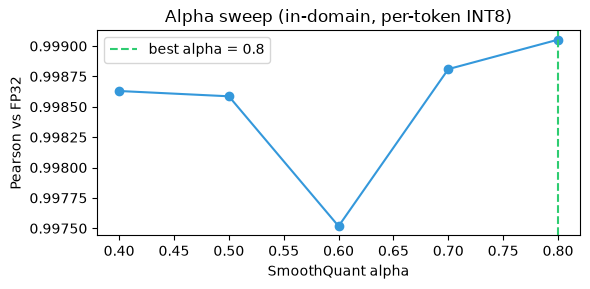

Best alpha = 0.8  (Pearson 0.9991)

In [11]:
sweep = []
for a in ALPHAS:
    m, folds = build_variant(smooth=True, act_mode="per_token", alpha=a)
    fid = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL)
    sweep.append((a, fid["pearson"]))
    free(m)

best_alpha = max(sweep, key=lambda t: t[1])[0]
xs, ys = zip(*sweep)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xs, ys, "o-", color="#3498DB")
ax.axvline(best_alpha, color="#2ECC71", ls="--", label=f"best alpha = {best_alpha}")
ax.set_xlabel("SmoothQuant alpha")
ax.set_ylabel("Pearson vs FP32")
ax.set_title("Alpha sweep (in-domain, per-token INT8)")
ax.legend()
plt.tight_layout()
plt.show()

rprint(f"[dark_sea_green]Best alpha = {best_alpha}[/dark_sea_green]  (Pearson {dict(sweep)[best_alpha]:.4f})")

## Per-Component Ablation and Mixed Precision

Quantize one projection type at a time (SmoothQuant, per-token, best alpha) to see which costs the most fidelity. The un-smoothed `attn.Wo` and `mlp.Wo` have no preceding `LayerNorm` to absorb a smoothing scale - `mlp.Wo` in particular consumes the GeGLU product - so they are the likely worst offenders. The most damaging component is then held in FP (kept out of the INT8 target set) to test a mixed-precision configuration.

In [12]:
abl_rows = []
for t in QUANT_TARGETS:
    m, _ = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=(t,))
    fid = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL)
    abl_rows.append((t, fid["pearson"]))
    free(m)

worst = min(abl_rows, key=lambda r: r[1])[0]      # quantizing this one alone hurts most
mixed_targets = tuple(t for t in QUANT_TARGETS if t != worst)

m, _ = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=QUANT_TARGETS)
fid_full = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL); free(m)
m, _ = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=mixed_targets)
fid_mixed = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL); free(m)

table = Table(title=f"Per-component ablation (solo INT8, alpha={best_alpha})")
table.add_column("only-quantized component", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
for t, p in abl_rows:
    style = "indian_red" if t == worst else "dark_sea_green"
    table.add_row(t, f"[{style}]{p:.4f}[/{style}]")
console.print(table)
rprint(
    f"[steel_blue]Most damaging:[/steel_blue] [indian_red]{worst}[/indian_red]   "
    f"full-INT8 Pearson [dark_sea_green]{fid_full['pearson']:.4f}[/dark_sea_green]  "
    f"vs mixed (keep {worst} FP) [dark_sea_green]{fid_mixed['pearson']:.4f}[/dark_sea_green]"
)

  Per-component ablation (solo INT8,  
              alpha=0.8)              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ only-quantized component ┃ Pearson ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ attn.Wqkv                │  0.9996 │
│ attn.Wo                  │  0.9998 │
│ mlp.Wi                   │  0.9997 │
│ mlp.Wo                   │  0.9994 │
└──────────────────────────┴─────────┘

Most damaging: mlp.Wo   full-INT8 Pearson 0.9991  vs mixed (keep mlp.Wo FP) 0.9996

## Chosen Configuration

Picks the deployment configuration: full INT8 unless dropping the worst component to FP buys a meaningful Pearson gain (threshold 0.005, since mixed precision costs one un-quantized projection per layer). The choice and its in-domain plus synthetic fidelity are recorded for Part B and for the embedding stage.

In [13]:
use_mixed = (fid_mixed["pearson"] - fid_full["pearson"]) > 0.005
chosen_targets = mixed_targets if use_mixed else QUANT_TARGETS
chosen_fid_dom = fid_mixed if use_mixed else fid_full

m, folds = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=chosen_targets)
chosen_fid_syn = fidelity(emb_fp_syn, sims_fp_syn, m, EVAL_SENTENCES)
free(m)

best_config = {
    "model": MODEL_NAME,
    "alpha": best_alpha,
    "act_mode": "per_token",
    "weight_quant": "per_channel_symmetric_int8",
    "targets": list(chosen_targets),
    "mixed_precision": use_mixed,
    "fp_component": worst if use_mixed else None,
    "n_smooth_folds": int(folds),
    "fidelity_in_domain": chosen_fid_dom,
    "fidelity_synthetic": chosen_fid_syn,
}

rprint(f"""[bold medium_purple]Chosen configuration[/bold medium_purple]
[dim]{"─" * 44}[/dim]
  Alpha: [dark_sea_green]{best_alpha}[/dark_sea_green]   Activations: [grey70]per_token[/grey70]
  Mixed precision: [grey70]{use_mixed}[/grey70]{f" (keep {worst} in FP)" if use_mixed else ""}
  In-domain Pearson: [dark_sea_green]{chosen_fid_dom['pearson']:.4f}[/dark_sea_green]   Spearman: [dark_sea_green]{chosen_fid_dom['spearman']:.4f}[/dark_sea_green]
  Synthetic Pearson: [dark_sea_green]{chosen_fid_syn['pearson']:.4f}[/dark_sea_green]
""")

Chosen configuration
────────────────────────────────────────────
  Alpha: 0.8   Activations: per_token
  Mixed precision: False
  In-domain Pearson: 0.9991   Spearman: 0.9991
  Synthetic Pearson: 0.9980

# Part B - Real OpenVINO INT8 Deployment

Part A measured quality by simulation. Part B materializes the chosen configuration as a real, runnable INT8 model so the fidelity gain becomes actual latency and memory savings.

The torch model is converted to OpenVINO with `openvino.convert_model` (architecture-agnostic graph tracing - it sidesteps `optimum-intel`, whose OpenVINO exporter does not yet support the ModernBERT architecture), then quantized to INT8 by **NNCF** with its built-in SmoothQuant at the alpha chosen in Part A, calibrated on the in-domain statements. NNCF re-derives the smoothing scales on the OpenVINO graph, so the real INT8 numbers will differ slightly from the simulation - the verification step below checks they land close. OpenVINO INT8 executes on **CPU** (there is no OV INT8 path on the NVIDIA GPU), matching the deployment target of the project's other quantized models.

## Convert and Quantize

Frees the GPU, converts the FP32 encoder to an OpenVINO graph, and runs NNCF INT8 PTQ with SmoothQuant (`matmul` alpha = the Part A `best_alpha`) on the in-domain calibration set. The deployable IR is written to `models/00-mmbert-openvino-int8/`.

In [14]:
import openvino as ov
import nncf
from nncf.quantization.advanced_parameters import (
    AdvancedQuantizationParameters, AdvancedSmoothQuantParameters,
)

# OpenVINO runs on CPU - free the GPU
model_cpu = copy.deepcopy(model_fp).cpu().eval()
if torch.cuda.is_available():
    model_fp.cpu()
    torch.cuda.empty_cache()


def ov_feed(sents):
    e = tokenizer(
        sents, return_tensors="np", padding="max_length", truncation=True, max_length=MAX_LEN
    )
    return {"input_ids": e["input_ids"], "attention_mask": e["attention_mask"]}


_ex = ov_feed(["a calibration example sentence."])
ov_fp = ov.convert_model(model_cpu, example_input=_ex)

calib_ds = nncf.Dataset([ov_feed([s]) for s in DOMAIN_CALIB])
adv = AdvancedQuantizationParameters(
    smooth_quant_alphas=AdvancedSmoothQuantParameters(matmul=best_alpha)
)
ov_int8 = nncf.quantize(
    ov_fp, calib_ds, model_type=nncf.ModelType.TRANSFORMER,
    advanced_parameters=adv, subset_size=len(DOMAIN_CALIB),
)

OV_DIR.mkdir(parents=True, exist_ok=True)
ov.save_model(ov_int8, str(OV_DIR / "openvino_model.xml"))
tokenizer.save_pretrained(OV_DIR)
rprint(
    f"[dark_sea_green]✓[/dark_sea_green] OpenVINO INT8 (SmoothQuant alpha="
    f"[dark_sea_green]{best_alpha}[/dark_sea_green]) → [dim]{OV_DIR}[/dim]"
)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


/home/lab/.local/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


Output()

Output()

Output()

✓ OpenVINO INT8 (SmoothQuant alpha=0.8) → 
/home/lab/workspace/learning/projects/docdistance-estimator/models/02-mmbert-openvino-int8

## Verify Deployed INT8

Embeds both corpora with the real INT8 OpenVINO model on CPU and correlates against the FP32 torch baseline. The question: does the deployed model keep the fidelity the simulation promised? The real Pearson should sit close to the Part A chosen-config number.

In [15]:
core = ov.Core()
cm_fp = core.compile_model(ov_fp, "CPU")
cm_int8 = core.compile_model(ov_int8, "CPU")


def embed_ov(compiled, sents):
    op = compiled.outputs[0]
    vecs = []
    for s in sents:
        e = tokenizer(s, return_tensors="np", padding="max_length", truncation=True, max_length=MAX_LEN)
        r = compiled({"input_ids": e["input_ids"], "attention_mask": e["attention_mask"]})[op]
        mask = e["attention_mask"][..., None].astype("float32")
        v = (r * mask).sum(1) / np.clip(mask.sum(1), 1e-9, None)
        vecs.append((v / np.linalg.norm(v, axis=-1, keepdims=True))[0])
    return torch.tensor(np.stack(vecs))


emb_ov_dom = embed_ov(cm_int8, DOMAIN_EVAL)
sims_ov_dom = pairwise_sims(emb_ov_dom)
real_int8 = {
    "pearson": float(pearsonr(sims_fp_dom, sims_ov_dom)[0]),
    "spearman": float(spearmanr(sims_fp_dom, sims_ov_dom)[0]),
    "emb_cos": float(F.cosine_similarity(emb_fp_dom, emb_ov_dom).mean().item()),
}

table = Table(title="Deployed INT8 vs simulation (in-domain)")
table.add_column("source", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
table.add_column("Spearman", style="dark_sea_green", justify="right")
table.add_column("emb cos", style="steel_blue", justify="right")
table.add_row("Part A simulation", f"{chosen_fid_dom['pearson']:.4f}",
              f"{chosen_fid_dom['spearman']:.4f}", f"{chosen_fid_dom['emb_cos']:.4f}")
table.add_row("real OpenVINO INT8", f"{real_int8['pearson']:.4f}",
              f"{real_int8['spearman']:.4f}", f"{real_int8['emb_cos']:.4f}")
console.print(table)

       Deployed INT8 vs simulation (in-domain)       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ source             ┃ Pearson ┃ Spearman ┃ emb cos ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ Part A simulation  │  0.9991 │   0.9991 │  0.9987 │
│ real OpenVINO INT8 │  0.9916 │   0.9927 │  0.9939 │
└────────────────────┴─────────┴──────────┴─────────┘

## Benchmark

Median CPU latency per sentence and on-disk IR size, FP vs INT8. INT8 should be smaller and faster; the exact speedup depends on CPU INT8 kernel support.

In [16]:
import os as _os

sample = DOMAIN_EVAL[: min(16, len(DOMAIN_EVAL))]


def bench(compiled, repeats=5):
    embed_ov(compiled, sample)  # warmup
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        embed_ov(compiled, sample)
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts)) / len(sample) * 1000.0   # ms / sentence


FP_TMP = Path("/tmp/ov_fp_size")
FP_TMP.mkdir(parents=True, exist_ok=True)
ov.save_model(ov_fp, str(FP_TMP / "openvino_model.xml"))


def ir_size_mb(d):
    return sum(_os.path.getsize(d / f) for f in _os.listdir(d)
               if (d / f).is_file() and f.startswith("openvino_model")) / 1e6


lat_fp, lat_int8 = bench(cm_fp), bench(cm_int8)
mb_fp, mb_int8 = ir_size_mb(FP_TMP), ir_size_mb(OV_DIR)

rprint(f"""[bold medium_purple]OpenVINO CPU benchmark[/bold medium_purple]
[dim]{"─" * 44}[/dim]
  Latency/sentence - FP [light_sea_green]{lat_fp:.1f} ms[/light_sea_green]  →  INT8 [light_sea_green]{lat_int8:.1f} ms[/light_sea_green]  ([dark_sea_green]{lat_fp / lat_int8:.2f}x[/dark_sea_green])
  IR size - FP [light_sea_green]{mb_fp:.0f} MB[/light_sea_green]  →  INT8 [light_sea_green]{mb_int8:.0f} MB[/light_sea_green]  ([dark_sea_green]{mb_fp / mb_int8:.2f}x[/dark_sea_green])
""")

OpenVINO CPU benchmark
────────────────────────────────────────────
  Latency/sentence - FP 30.6 ms  →  INT8 21.4 ms  (1.43x)
  IR size - FP 615 MB  →  INT8 310 MB  (1.98x)

# Part C - GPU Quantization Sweep (torchao)

Frees the Part A/B models, reloads mmBERT in bf16 on the GPU, and sweeps torchao INT8/FP8 schemes with `torch.compile`. The FP32 gold embeddings from Part A are reused as the fidelity reference; the bf16 model (eager and compiled) is the speed baseline that quantization must beat.

In [17]:
import gc

# free Part A/B torch models, reload bf16 base for the GPU sweep
for _n in ["model_fp", "model_cpu"]:
    if _n in globals():
        try:
            globals()[_n].cpu()
        except Exception:
            pass
        del globals()[_n]
gc.collect()
torch.cuda.empty_cache()

base = (
    AutoModel.from_pretrained(MODEL_NAME, config=cfg, attn_implementation="eager",
                              torch_dtype=torch.bfloat16)
    .to(device).eval()
)
# reuse Part A FP32 gold as the fidelity reference
emb_gold_dom, sims_gold_dom = emb_fp_dom, sims_fp_dom
emb_gold_syn, sims_gold_syn = emb_fp_syn, sims_fp_syn
rprint("[dark_sea_green]✓[/dark_sea_green] bf16 base reloaded; FP32 gold reused from Part A")

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ bf16 base reloaded; FP32 gold reused from Part A

## bf16 Baselines

The bf16 model, eager and `torch.compile`d, is the speed bar quantization must beat. Compiling bf16 alone is already a large win, so the fair question for each quant scheme is whether it beats *compiled* bf16.

In [18]:
results = {}

fid_bf16 = fidelity(emb_gold_dom, sims_gold_dom, base, DOMAIN_EVAL)
tp_eager, lat_eager = throughput(base)
results["bf16_eager"] = {**fid_bf16, "sent_per_s": tp_eager, "ms_per_sent": lat_eager}

base_compiled = torch.compile(copy.deepcopy(base))
tp_cbf, lat_cbf = throughput(base_compiled)
results["bf16_compiled"] = {**fid_bf16, "sent_per_s": tp_cbf, "ms_per_sent": lat_cbf}
del base_compiled; torch.cuda.empty_cache()

rprint(
    f"[steel_blue]bf16 eager[/steel_blue] [dark_sea_green]{tp_eager:.0f}[/dark_sea_green] sent/s   "
    f"[steel_blue]bf16 compiled[/steel_blue] [dark_sea_green]{tp_cbf:.0f}[/dark_sea_green] sent/s "
    f"([dark_sea_green]{tp_cbf/tp_eager:.2f}x[/dark_sea_green] from compile alone)"
)

bf16 eager 1196 sent/s   bf16 compiled 2281 sent/s (1.91x from compile alone)

## torchao Sweep

For each scheme: quantize a bf16 copy in place, `torch.compile`, then measure fidelity vs FP32 (in-domain + synthetic) and compiled throughput. A scheme that errors (missing kernel on this torch/GPU) is recorded as failed and skipped, not fatal.

In [19]:
for name, Cfg in SCHEMES.items():
    try:
        m = copy.deepcopy(base)
        quantize_(m, Cfg())
        fid = fidelity(emb_gold_dom, sims_gold_dom, m, DOMAIN_EVAL)
        fid_syn = fidelity(emb_gold_syn, sims_gold_syn, m, SYN_EVAL)
        mc = torch.compile(m)
        tp, lat = throughput(mc)
        results[name] = {
            **fid, "pearson_syn": fid_syn["pearson"],
            "sent_per_s": tp, "ms_per_sent": lat,
            "speedup_vs_bf16_eager": tp / tp_eager,
            "speedup_vs_bf16_compiled": tp / tp_cbf,
        }
        rprint(
            f"[dark_sea_green]✓[/dark_sea_green] [cadet_blue]{name}[/cadet_blue] "
            f"Pearson [dark_sea_green]{fid['pearson']:.4f}[/dark_sea_green]  "
            f"[dark_sea_green]{tp:.0f}[/dark_sea_green] sent/s  "
            f"[dark_sea_green]{tp/tp_cbf:.2f}x[/dark_sea_green] vs bf16-compiled"
        )
        del m, mc; torch.cuda.empty_cache()
    except Exception as e:
        results[name] = {"failed": f"{type(e).__name__}: {str(e)[:160]}"}
        rprint(f"[indian_red]✗ {name} failed:[/indian_red] [grey70]{type(e).__name__}[/grey70]")

/home/lab/.local/lib/python3.13/site-packages/torchao/quantization/quant_api.py:936: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/lab/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/lab/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/lab/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is

/home/lab/.local/lib/python3.13/site-packages/torch/_functorch/_aot_autograd/autograd_cache.py:542: UserWarning: AffineQuantizedTensor does not implement _stable_hash_for_caching. For PT2-compatible tensor subclasses, it is recommended to implement _stable_hash_for_caching(self) -> str for stable AOT autograd caching.
  warn_once(


✓ int8_weight_only Pearson 0.9996  33 sent/s  0.01x vs bf16-compiled

/home/lab/.local/lib/python3.13/site-packages/torch/_functorch/_aot_autograd/autograd_cache.py:542: UserWarning: LinearActivationQuantizedTensor does not implement _stable_hash_for_caching. For PT2-compatible tensor subclasses, it is recommended to implement _stable_hash_for_caching(self) -> str for stable AOT autograd caching.
  warn_once(


✓ int8_dynamic_w8a8 Pearson 0.9717  2052 sent/s  0.90x vs bf16-compiled

/home/lab/.local/lib/python3.13/site-packages/torch/_functorch/_aot_autograd/autograd_cache.py:542: UserWarning: Float8Tensor does not implement _stable_hash_for_caching. For PT2-compatible tensor subclasses, it is recommended to implement _stable_hash_for_caching(self) -> str for stable AOT autograd caching.
  warn_once(


✓ fp8_dynamic_e4m3 Pearson 0.9985  2588 sent/s  1.13x vs bf16-compiled

## Results and Sweet Spot

The full sweep, then the GPU pick: among schemes clearing the fidelity floor, the one with the highest throughput. FP8 dynamic is expected to win - it uses the Ada's FP8 tensor cores and beats even compiled bf16 at near-lossless fidelity.

In [20]:
order = ["bf16_eager", "bf16_compiled"] + list(SCHEMES)
table = Table(title="mmBERT GPU quantization sweep (Ada, batch 128 x seq 128)")
table.add_column("scheme", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
table.add_column("sent/s", style="steel_blue", justify="right")
table.add_column("x bf16-eager", style="dark_sea_green", justify="right")
table.add_column("x bf16-compiled", style="dark_sea_green", justify="right")
for k in order:
    r = results[k]
    if "failed" in r:
        table.add_row(k, "[indian_red]FAIL[/indian_red]", "-", "-", "-")
        continue
    se = r.get("speedup_vs_bf16_eager", r["sent_per_s"] / results["bf16_eager"]["sent_per_s"])
    sc = r.get("speedup_vs_bf16_compiled", r["sent_per_s"] / results["bf16_compiled"]["sent_per_s"])
    table.add_row(k, f"{r['pearson']:.4f}", f"{r['sent_per_s']:.0f}", f"{se:.2f}x", f"{sc:.2f}x")
console.print(table)

eligible = {
    k: results[k] for k in SCHEMES
    if "failed" not in results[k] and results[k]["pearson"] >= FIDELITY_FLOOR
}
best_gpu = max(eligible, key=lambda k: eligible[k]["sent_per_s"])
bg = results[best_gpu]
rprint(
    f"[bold dark_sea_green]GPU sweet spot: {best_gpu}[/bold dark_sea_green] - "
    f"Pearson [dark_sea_green]{bg['pearson']:.4f}[/dark_sea_green], "
    f"[dark_sea_green]{bg['sent_per_s']:.0f}[/dark_sea_green] sent/s "
    f"([dark_sea_green]{bg['speedup_vs_bf16_eager']:.2f}x[/dark_sea_green] vs eager bf16)"
)

        mmBERT GPU quantization sweep (Ada, batch 128 x seq 128)         
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ scheme            ┃ Pearson ┃ sent/s ┃ x bf16-eager ┃ x bf16-compiled ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bf16_eager        │  0.9996 │   1196 │        1.00x │           0.52x │
│ bf16_compiled     │  0.9996 │   2281 │        1.91x │           1.00x │
│ int8_weight_only  │  0.9996 │     33 │        0.03x │           0.01x │
│ int8_dynamic_w8a8 │  0.9717 │   2052 │        1.72x │           0.90x │
│ fp8_dynamic_e4m3  │  0.9985 │   2588 │        2.16x │           1.13x │
└───────────────────┴─────────┴────────┴──────────────┴─────────────────┘

GPU sweet spot: fp8_dynamic_e4m3 - Pearson 0.9985, 2588 sent/s (2.16x vs eager bf16)

## Throughput Chart

Sentences/second per scheme (failed schemes omitted), with the bf16 baselines for reference.

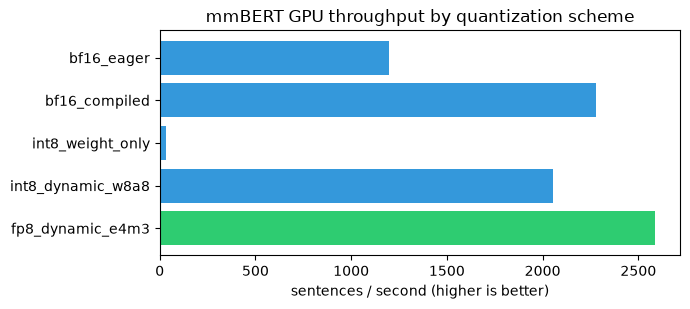

In [21]:
labels = [k for k in order if "failed" not in results[k]]
vals = [results[k]["sent_per_s"] for k in labels]
colors = ["#2ECC71" if k == best_gpu else "#3498DB" for k in labels]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(labels, vals, color=colors)
ax.set_xlabel("sentences / second (higher is better)")
ax.set_title("mmBERT GPU throughput by quantization scheme")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Best Model Selection and Export

Selects the best model per target - CPU (OpenVINO INT8, from Part B) and GPU (highest-throughput torchao scheme above the fidelity floor, from Part C) - and writes the recipes. The GPU pick is the headline (highest fidelity and fastest); the CPU pick is the GPU-free deployable. Re-running this notebook always regenerates these.

In [22]:
cpu_best = {
    "target": "cpu",
    "toolchain": "openvino",
    "scheme": "smoothquant_int8_per_tensor_static",
    "artifact": str(OV_DIR),
    "pearson_in_domain": real_int8["pearson"],
    "latency_ms_per_sentence": lat_int8,
    "ir_size_mb": mb_int8,
    "smoothquant_alpha": best_alpha,
}
gpu_best = {
    "target": "gpu",
    "toolchain": "torchao",
    "scheme": best_gpu,
    "torchao_config": type(SCHEMES[best_gpu]()).__name__,
    "apply": "quantize_(model, <config>()) on the FP checkpoint, then torch.compile (needs C compiler)",
    "pearson_in_domain": bg["pearson"],
    "sent_per_s": bg["sent_per_s"],
    "speedup_vs_bf16_eager": bg["speedup_vs_bf16_eager"],
    "speedup_vs_bf16_compiled": bg["speedup_vs_bf16_compiled"],
}
# headline best = the higher-fidelity deployable (GPU FP8 reaches ~0.99 vs CPU ~0.96)
recommended = "gpu" if gpu_best["pearson_in_domain"] >= cpu_best["pearson_in_domain"] else "cpu"

best_config = {
    "model": MODEL_NAME,
    "recommended_target": recommended,
    "cpu": cpu_best,
    "gpu": gpu_best,
    "smoothquant_study": best_config if "best_config" in globals() else None,
}
metrics = {
    "model": MODEL_NAME,
    "n_params_millions": round(n_params / 1e6, 1),
    "part_a_scheme_comparison": [
        {"smoothing": sm, "activations": act, **fid} for sm, act, fid in scheme_rows
    ],
    "part_a_alpha_sweep": [{"alpha": a, "pearson": p} for a, p in sweep],
    "part_a_best_alpha": best_alpha,
    "part_b_cpu_openvino_int8": {
        **real_int8,
        "latency_ms_per_sentence_int8": lat_int8,
        "latency_ms_per_sentence_fp": lat_fp,
        "ir_size_mb_int8": mb_int8,
        "ir_size_mb_fp": mb_fp,
    },
    "part_c_gpu_sweep": {"workload": {"batch": BENCH_BATCH, "seq": BENCH_SEQ}, "results": results},
    "best_cpu": cpu_best,
    "best_gpu": gpu_best,
    "recommended_target": recommended,
}

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(metrics, indent=2, default=float))
BESTCFG_PATH.write_text(json.dumps(best_config, indent=2, default=float))

panel = Table(title="BEST MODEL per target")
panel.add_column("target", style="grey70")
panel.add_column("scheme", style="grey70")
panel.add_column("Pearson", style="dark_sea_green", justify="right")
panel.add_column("performance", style="steel_blue", justify="right")
panel.add_row("CPU", "OpenVINO INT8", f"{cpu_best['pearson_in_domain']:.3f}",
              f"{cpu_best['latency_ms_per_sentence']:.1f} ms/sent")
panel.add_row(f"GPU{'  <- recommended' if recommended=='gpu' else ''}",
              f"torchao {best_gpu}", f"{gpu_best['pearson_in_domain']:.3f}",
              f"{gpu_best['sent_per_s']:.0f} sent/s")
console.print(panel)
rprint(
    f"[dark_sea_green]✓[/dark_sea_green] metrics → [dim]{METRICS_PATH}[/dim]\n"
    f"[dark_sea_green]✓[/dark_sea_green] best config → [dim]{BESTCFG_PATH}[/dim]\n"
    f"[dark_sea_green]✓[/dark_sea_green] CPU IR → [dim]{OV_DIR}[/dim]"
)

                           BEST MODEL per target                           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ target              ┃ scheme                   ┃ Pearson ┃  performance ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ CPU                 │ OpenVINO INT8            │   0.992 │ 21.4 ms/sent │
│ GPU  <- recommended │ torchao fp8_dynamic_e4m3 │   0.999 │  2588 sent/s │
└─────────────────────┴──────────────────────────┴─────────┴──────────────┘

✓ metrics → /home/lab/workspace/learning/projects/docdistance-estimator/reports/02-mmbert-quantization-metrics.json
✓ best config → /home/lab/workspace/learning/projects/docdistance-estimator/reports/02-mmbert-bestconfig.json
✓ CPU IR → /home/lab/workspace/learning/projects/docdistance-estimator/models/02-mmbert-openvino-int8